In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries imported successfully")

All Libraries imported successfully


In [140]:
df = sns.load_dataset('titanic')
print("Dataset loaded successfully")

Dataset loaded successfully


In [141]:
df.head()
#df.shape
#df.columns
#df.info()
#df.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [142]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

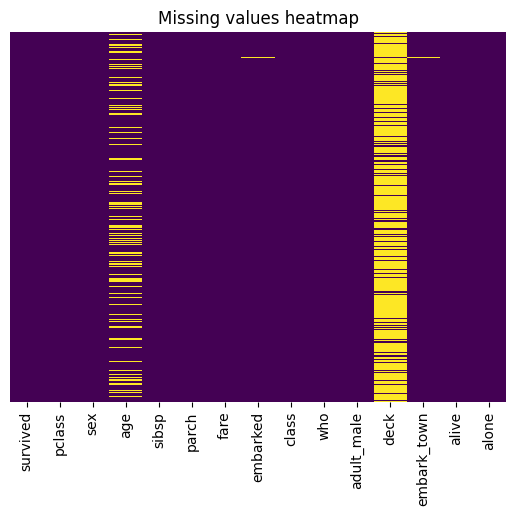

In [143]:
plt.Figure(figsize=(10,6))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title("Missing values heatmap")
plt.show()

In [144]:
df['age']= df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df=df.drop(columns=['deck','embark_town','alive','who','adult_male', 'alone'])
print(df.isnull().sum())



survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
dtype: int64


## Exploratory Data Analysis

##### Chart 1 — How many survived?

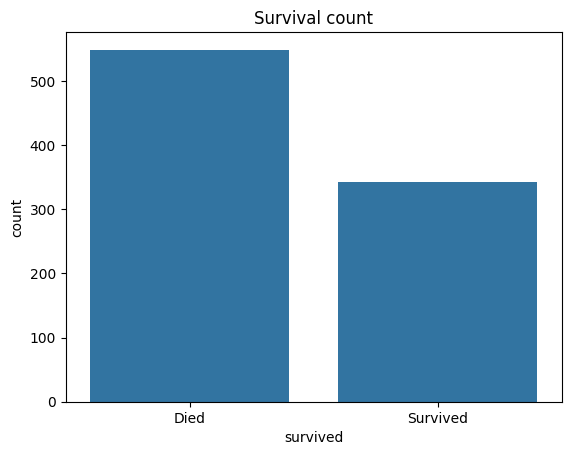

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [145]:
plt.Figure(figsize=(6,4))
sns.countplot(x='survived',data=df)
plt.title("Survival count")
plt.xticks([0,1],['Died','Survived'])
plt.show()
print(df['survived'].value_counts())
print(df['survived'].value_counts(normalize=True)*100)

#### Chart 2 — Survival by Gender

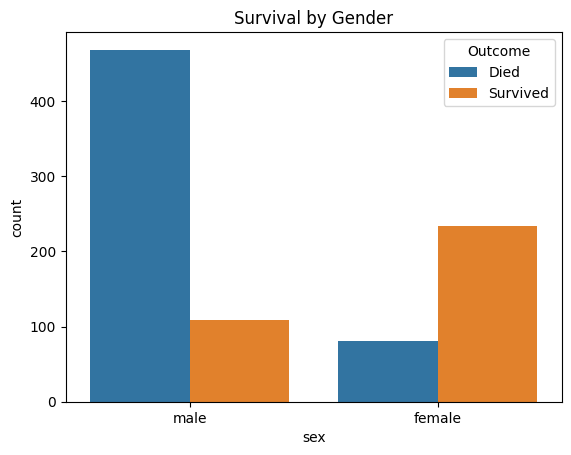

sex
male      577
female    314
Name: count, dtype: int64
sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


In [154]:
plt.Figure(figsize=(6,4))
sns.countplot(x='sex',data=df,hue='survived')
plt.title("Survival by Gender")
plt.legend(labels=['Died','Survived'],title='Outcome')
plt.show()

print(df['sex'].value_counts())
print(df['sex'].value_counts(normalize=True)*100)

#### Chart 3 — Survival by Passenger Class

<function matplotlib.pyplot.show(close=None, block=None)>

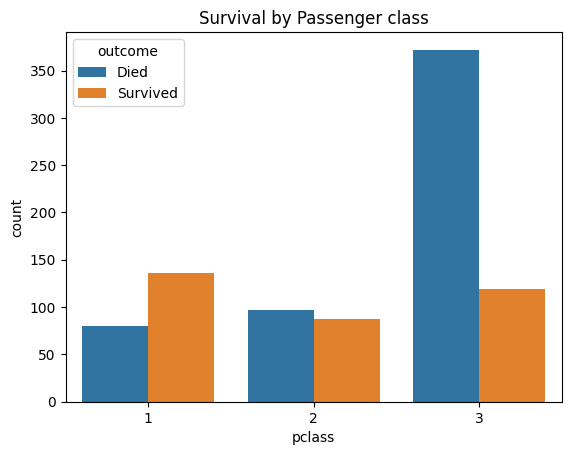

In [157]:
plt.Figure(figsize=(6,4))
sns.countplot(x='pclass',hue='survived',data=df)
plt.title('Survival by Passenger class')
plt.legend(labels=['Died','Survived'],title='outcome')
plt.show


#### Chart 4 — Age Distribution


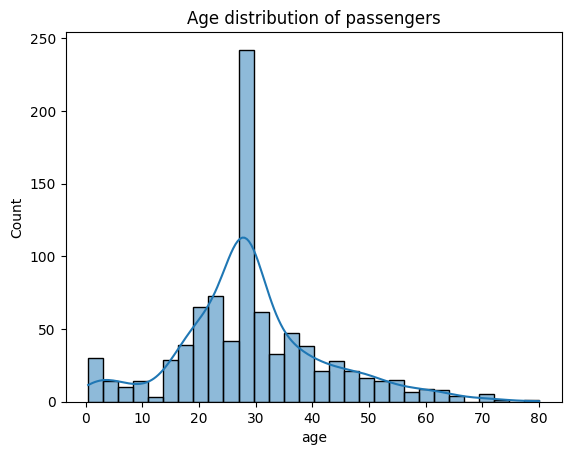

In [162]:
plt.Figure(figsize=(8,4))
sns.histplot(df['age'],bins=30,kde=True)
plt.title("Age distribution of passengers")
plt.show()

#### Chart 5 — Age vs Survival

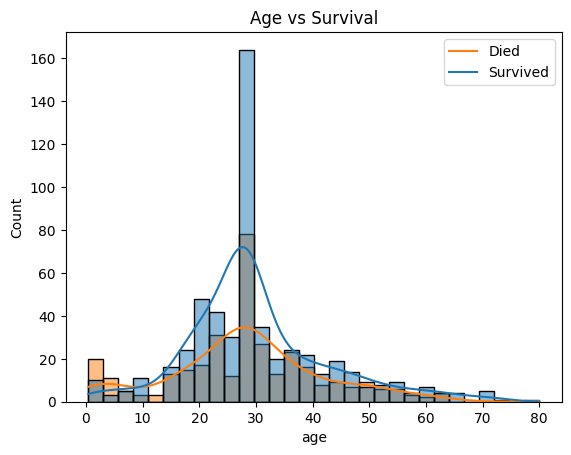

In [164]:
plt.Figure(figsize=(8,4))
sns.histplot(data=df,x='age',hue='survived',bins=30,kde=True)
plt.title("Age vs Survival")
plt.legend(labels=['Died','Survived'])
plt.show()